# 📚 Personal Setting

In [1]:
from tsel_aagm.matching import *
from tsel_aagm.azuka_charts import *


In [2]:
# from causalinference_aagm.matching import PropensityScoreMatch as psm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# plt.style.use('seaborn')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import matplotlib as mpl
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
import importlib

# font_path = '/data/vscode/azkaram/azkaram/04_attributes/fonts/Poppins-Regular.ttf'
# font_path_bold = '/data/vscode/azkaram/azkaram/04_attributes/fonts/Poppins-Bold.ttf'

font_path = '/Users/azkaram/Documents/01_Development/05_python/02_data_vis_library/fonts/Poppins-Regular.ttf'
font_path_bold = '/Users/azkaram/Documents/01_Development/05_python/02_data_vis_library/fonts/Poppins-Bold.ttf'

custom_font = fm.FontProperties(fname=font_path).get_name()
custom_font_bold = fm.FontProperties(fname=font_path_bold).get_name()
fm.fontManager.addfont(font_path)
fm.fontManager.addfont(font_path_bold)

custom_colors = ['#0472f7', '#06b45e', '#fc3d51', '#66d2ff', '#dab236', '#c1a2c2']
blue, green, red, sky, yellow, purple = custom_colors

import matplotlib as mpl

# Define themes
themes = {
    "dark": {
        "background": "#282c34",
        "edge": "#444444",
        "text": "#BBBBBB",
        "grid": "#444444"
    },
    "light": {
        "background": "#FFFFFF",
        "edge": "#CCCCCC",
        "text": "#686868",
        "grid": "#DDDDDD"
    }
}

def set_theme(name="dark", custom_font="DejaVu Sans", custom_colors=None, bar_edge=False):
    """
    Switch between light and dark Matplotlib themes.
    
    Parameters
    ----------
    name : str
        "dark" or "light"
    custom_font : str
        Font family to use
    custom_colors : list
        Custom color cycle (hex codes or matplotlib colors)
    bar_edge : bool or str
        - False: no edge color on bars
        - True: use default edge
        - str: hex color or named color for bar edges
    """
    if name not in themes:
        raise ValueError(f"Theme '{name}' not found. Choose from {list(themes.keys())}")

    theme = themes[name]

    # default edgecolor setting
    if bar_edge is False:
        patch_edge = "none"   # no edge
    elif bar_edge is True:
        patch_edge = theme["edge"]  # use theme edge
    else:
        patch_edge = bar_edge  # user-specified color

    mpl.rcParams.update({
        'axes.facecolor': theme["background"],
        'axes.edgecolor': theme["edge"],
        'axes.labelcolor': theme["text"],
        'figure.facecolor': theme["background"],
        'figure.edgecolor': theme["edge"],
        'savefig.facecolor': theme["background"],
        'savefig.edgecolor': theme["edge"],
        'xtick.color': theme["text"],
        'ytick.color': theme["text"],
        'grid.color': theme["grid"],
        'text.color': theme["text"],
        'axes.grid': True,
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.spines.left': True,
        'axes.spines.bottom': True,
        'grid.linestyle': '--',
        'grid.alpha': 0.8,
        'lines.linewidth': 2,
        'font.size': 12,
        'font.family': custom_font,
        'axes.prop_cycle': mpl.cycler(color=custom_colors if custom_colors else plt.rcParams['axes.prop_cycle'].by_key()['color']),
        'patch.edgecolor': patch_edge,
        'patch.linewidth': 0.8 if bar_edge else 0  # line width 0 if no edge
    })

set_theme('dark', custom_font=custom_font, custom_colors=custom_colors)

In [4]:
def best_format(value):
    try:
        num = float(value)
    except (TypeError, ValueError):
        return value  # non-numeric → pass through unchanged

    # ── 2️⃣  Pretty-print the numeric value ─────────────────────────────────────
    if abs(num) >= 1_000_000_000:
        return f"{num / 1_000_000_000:.1f} Bn"
    elif abs(num) >= 1_000_000:
        return f"{num / 1_000_000:.1f} Mn"
    elif abs(num) >= 1_000:
        return f"{num / 1_000:.1f} K"
    else:
        return f"{num:.1f}"

def best_fmt(value, tick_number):
    if abs(value) >= 1_000_000_000:
        return f'{value/1_000_000_000:.1f} Bn'
    elif abs(value) >= 1_000_000:
        return f'{value/1_000_000:.1f} Mn'
    elif abs(value) >= 1_000:
        return f'{value/1_000:.1f} K'
    else:
        return f'{value:.1f}'
# ax.xaxis.set_major_formatter(FuncFormatter(best_fmt))


In [5]:
df = pd.read_csv('datasets/healtcare_stroke_data.csv')
def one_hot_encode(df):
    """
    One-hot encodes all object data type columns of a Pandas DataFrame.
    """
    # Get the object columns
    obj_cols = df.select_dtypes(include=['object']).columns
    # One-hot encode the object columns
    df = pd.get_dummies(df, columns=obj_cols)
    return df

df = one_hot_encode(df).fillna(0)
df.head()
df_model = df[['age','hypertension','heart_disease','bmi','stroke','gender_Male','smoking_status_smokes', 'avg_glucose_level']]
df_model.head()

,age,hypertension,heart_disease,bmi,stroke,gender_Male,smoking_status_smokes,avg_glucose_level
0,67.0,0,1,36.6,1,True,False,228.69
1,61.0,0,0,0.0,1,False,False,202.21
2,80.0,0,1,32.5,1,True,False,105.92
3,49.0,0,0,34.4,1,False,True,171.23
4,79.0,1,0,24.0,1,False,False,174.12


In [6]:
df_model

,age,hypertension,heart_disease,bmi,stroke,gender_Male,smoking_status_smokes,avg_glucose_level
0,67.0,0,1,36.6,1,True,False,228.69
1,61.0,0,0,0.0,1,False,False,202.21
2,80.0,0,1,32.5,1,True,False,105.92
3,49.0,0,0,34.4,1,False,True,171.23
4,79.0,1,0,24.0,1,False,False,174.12
...,...,...,...,...,...,...,...,...
5105,80.0,1,0,0.0,0,False,False,83.75
5106,81.0,0,0,40.0,0,False,False,125.20
5107,35.0,0,0,30.6,0,False,False,82.99
5108,51.0,0,0,25.6,0,True,False,166.29


# Data Preparation

In [7]:
def hist_all_features(df, features, hue, name):
    width = 6*len(features)
    fig, axes = plt.subplots(ncols=len(features), figsize=(width, 5))
    for i in range(len(features)):
        sns.histplot(data=df, x=features[i], ax=axes[i], hue=hue)
    plt.tight_layout()
    plt.savefig(name)
    plt.show()


# Matching

In [8]:
df.groupby('smoking_status_smokes').count()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,gender_Other,...,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked
smoking_status_smokes,,,,,,,,,,,,,,,,,,,,,
False,4321,4321,4321,4321,4321,4321,4321,4321,4321,4321,...,4321,4321,4321,4321,4321,4321,4321,4321,4321,4321
True,789,789,789,789,789,789,789,789,789,789,...,789,789,789,789,789,789,789,789,789,789


In [9]:
features = ['age','hypertension','heart_disease','bmi','gender_Male', 'avg_glucose_level']
treatment = 'smoking_status_smokes'
outcome = 'stroke'

model = PropensityScoreMatch(df_model, features, treatment, outcome)

ATT: 0.010523591731563692
ATE: 0.010523591731563683
ATC: 0.010523591731563671


In [10]:
df_model

,age,hypertension,heart_disease,bmi,stroke,gender_Male,smoking_status_smokes,avg_glucose_level,proba,prediction
0,67.0,0,1,36.6,1,True,False,228.69,0.226680,False
1,61.0,0,0,0.0,1,False,False,202.21,0.134905,False
2,80.0,0,1,32.5,1,True,False,105.92,0.246842,False
3,49.0,0,0,34.4,1,False,True,171.23,0.154428,False
4,79.0,1,0,24.0,1,False,False,174.12,0.188637,False
...,...,...,...,...,...,...,...,...,...,...
5105,80.0,1,0,0.0,0,False,False,83.75,0.169714,False
5106,81.0,0,0,40.0,0,False,False,125.20,0.197430,False
5107,35.0,0,0,30.6,0,False,False,82.99,0.141411,False
5108,51.0,0,0,25.6,0,True,False,166.29,0.157281,False


# Evaluation

## Histogram

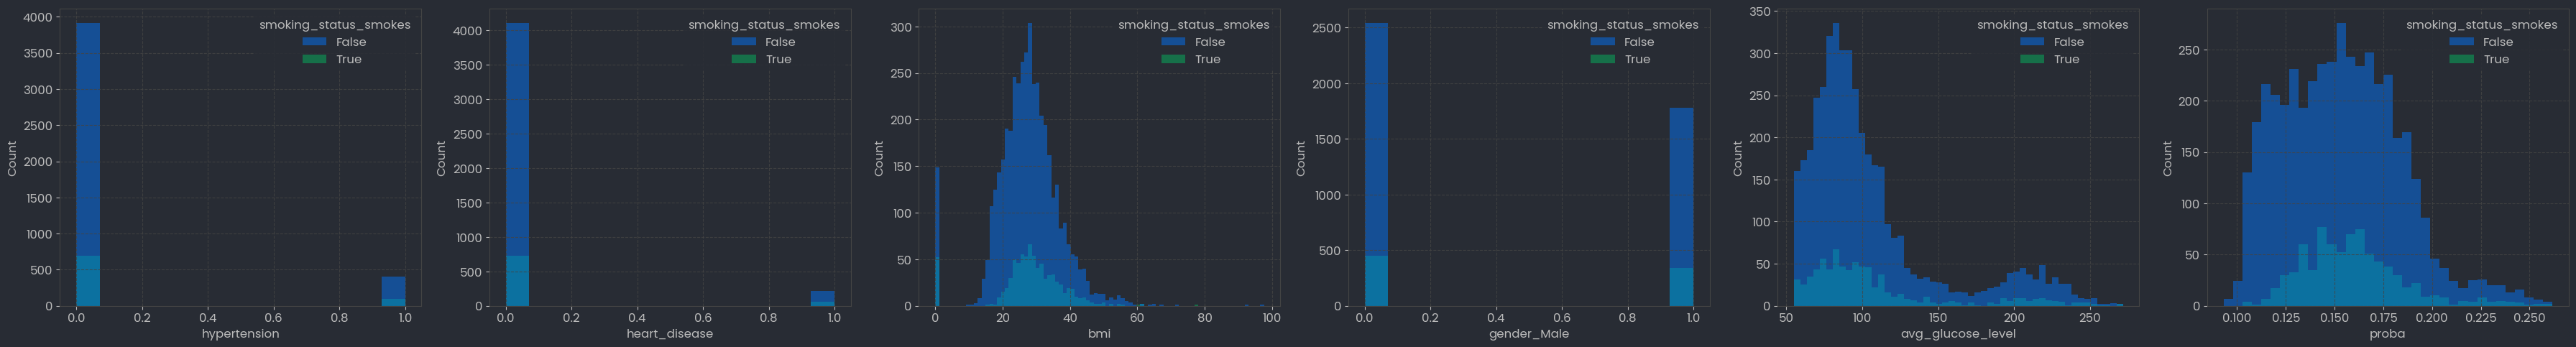

In [11]:
features = ['hypertension','heart_disease','bmi','gender_Male','avg_glucose_level','proba']
hist_all_features(model.df, features, hue='smoking_status_smokes', name='output/dist_1.png')

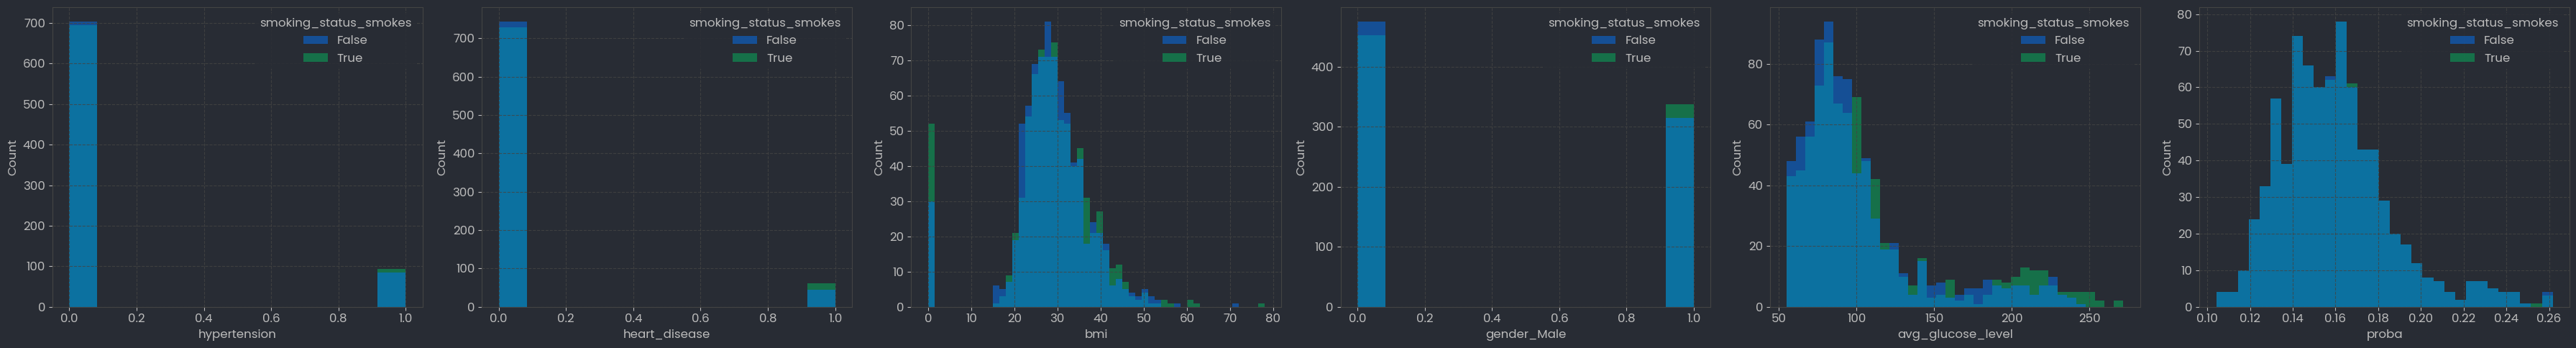

In [12]:
hist_all_features(model.df_matched, features, hue='smoking_status_smokes', name='output/dist_2.png')

## Histogram V2

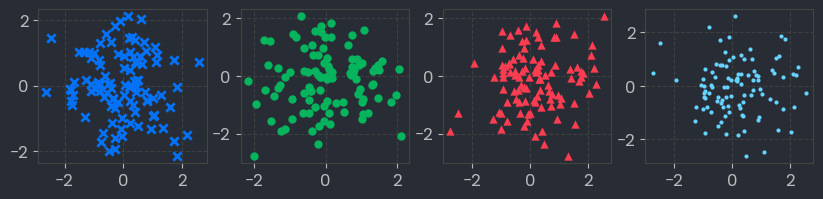

In [13]:
def my_plotter(ax, data1, data2, param_dict):
    """
    A helper function to make a graph.
    """
    ax.scatter(data1, data2, **param_dict)
    ax.set_axisbelow(True)
    
    return 

data1, data2, data3, data4 = np.random.randn(4, 100)  # make 4 random data sets
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 2))
my_plotter(ax1, data1, data2, {'marker': 'x', 'color':custom_colors[0]})
my_plotter(ax2, data2, data4, {'marker': 'o', 'color':custom_colors[1]})
my_plotter(ax3, data3, data4, {'marker': '^', 'color':custom_colors[2]})
my_plotter(ax4, data3, data1, {'marker': '.', 'color':custom_colors[3]})
plt.show()

In [14]:
# Refactor
def my_boxplot(ax, group_a, group_b, param_dict):
    # Boxplot with custom properties
    white = "#afafaf"
    bp = ax.boxplot(
        [group_a, group_b],
        vert=False,
        patch_artist=True,
        widths=0.8,
        boxprops=dict(facecolor=blue, color=white, linewidth=1, alpha=0.5),
        whiskerprops=dict(color=white, linewidth=1),
        capprops=dict(color=white, linewidth=1),
        medianprops=dict(color=white, linewidth=1),
        flierprops=dict(markerfacecolor=blue, markeredgecolor=white, markersize=6),
        **param_dict
    )
    ax.set_frame_on(False)
    # Set individual box colors
    colors = [green, blue]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    # --- Set flier (outlier) colors to match box colors ---
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor("#959595")
        flier.set_alpha(0.5)
    return 

In [15]:
# Refactor Box
def my_boxplot(ax, group_a, group_b, param_dict):
    # Boxplot with custom properties
    white = "#afafaf"
    bp = ax.boxplot(
        [group_a, group_b],
        vert=False,
        patch_artist=True,
        widths=0.8,
        boxprops=dict(facecolor=blue, color=white, linewidth=1, alpha=0.5),
        whiskerprops=dict(color=white, linewidth=1),
        capprops=dict(color=white, linewidth=1),
        medianprops=dict(color=white, linewidth=1),
        flierprops=dict(markerfacecolor=blue, markeredgecolor=white, markersize=6),
        **param_dict
    )
    ax.set_frame_on(False)
    # Set individual box colors
    colors = [green, blue]
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    # --- Set flier (outlier) colors to match box colors ---
    for flier, color in zip(bp['fliers'], colors):
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor("#959595")
        flier.set_alpha(0.5)
    return 

# Refactor Hist
def my_hist(ax, group_a, group_b, param_dict):
    ax.hist(group_a , bins=30, density=False, histtype="stepfilled", facecolor=custom_colors[1], alpha=0.1, edgecolor="none",)
    ax.hist(group_a , bins=30, density=False, histtype="step", color=custom_colors[1], linewidth=1.5, alpha=0.6)
    ax.hist(group_b , bins=30, density=False, histtype="stepfilled", facecolor=custom_colors[0], alpha=0.1, edgecolor="none",)
    ax.hist(group_b , bins=30, density=False, histtype="step", color=custom_colors[0], linewidth=1.5, alpha=0.6)
    ax.set_axisbelow(True)
    return 


# Data Taker
def take_data(data, feature):
    mask = data['smoking_status_smokes'] == True
    x1 = data[mask][feature]
    x2 = data[~mask][feature]
    return x1, x2



In [16]:
model.df

,age,hypertension,heart_disease,bmi,stroke,gender_Male,smoking_status_smokes,avg_glucose_level,proba,prediction
0,67.0,0,1,36.6,1,True,False,228.69,0.226680,False
1,61.0,0,0,0.0,1,False,False,202.21,0.134905,False
2,80.0,0,1,32.5,1,True,False,105.92,0.246842,False
3,49.0,0,0,34.4,1,False,True,171.23,0.154428,False
4,79.0,1,0,24.0,1,False,False,174.12,0.188637,False
...,...,...,...,...,...,...,...,...,...,...
5105,80.0,1,0,0.0,0,False,False,83.75,0.169714,False
5106,81.0,0,0,40.0,0,False,False,125.20,0.197430,False
5107,35.0,0,0,30.6,0,False,False,82.99,0.141411,False
5108,51.0,0,0,25.6,0,True,False,166.29,0.157281,False


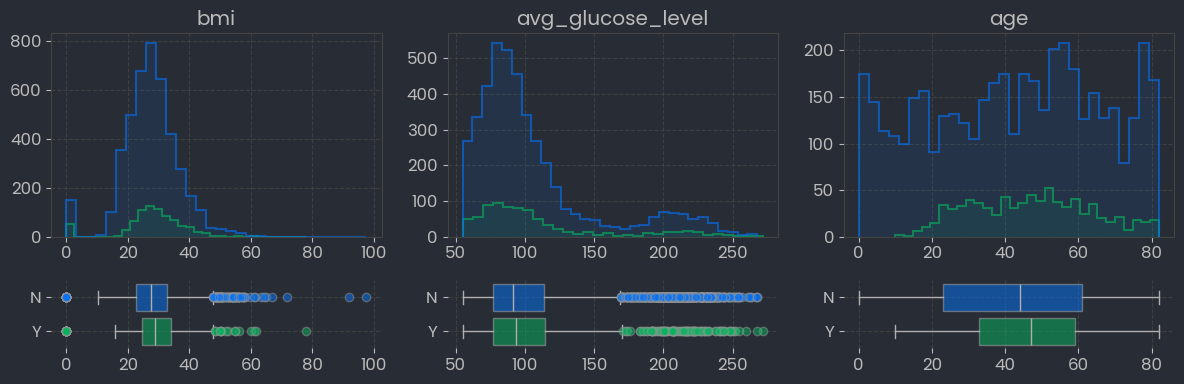

In [17]:


# Viz
r, c = 2, 3
fig, ax = plt.subplots(r, c, figsize=(4*c, 2*r), height_ratios=(3,1))

x1, x2 = take_data(model.df, 'bmi')
my_hist(ax[0,0], x1, x2, {})
my_boxplot(ax[1,0], x1, x2, {'labels':['Y', 'N']})

x1, x2 = take_data(model.df, 'avg_glucose_level')
my_hist(ax[0,1], x1, x2, {})
my_boxplot(ax[1,1], x1, x2, {'labels':['Y', 'N']})

x1, x2 = take_data(model.df, 'age')
my_hist(ax[0,2], x1, x2, {})
my_boxplot(ax[1,2], x1, x2, {'labels':['Y', 'N']})

# Adding Title
ax[0,0].set_title('bmi')
ax[0,1].set_title('avg_glucose_level')
ax[0,2].set_title('age')

plt.tight_layout()
plt.show()

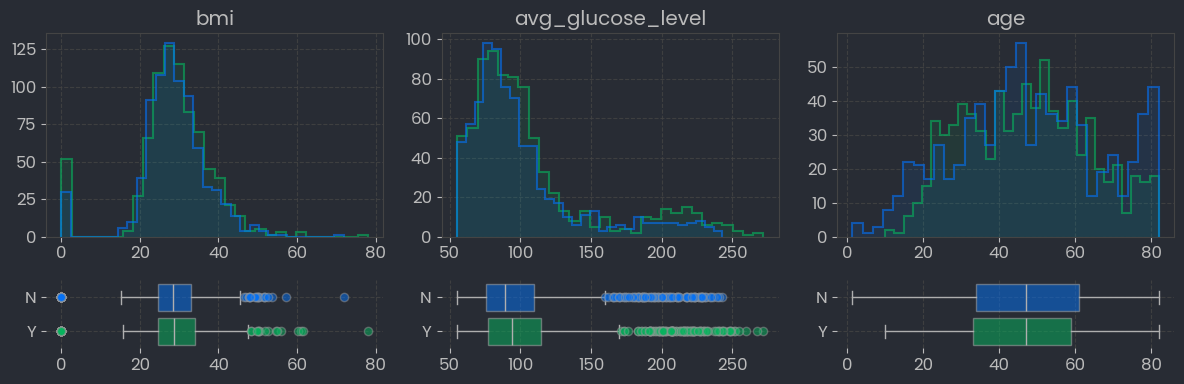

In [18]:
# Viz
r, c = 2, 3
fig, ax = plt.subplots(r, c, figsize=(4*c, 2*r), height_ratios=(3,1))

x1, x2 = take_data(model.df_matched, 'bmi')
my_hist(ax[0,0], x1, x2, {})
my_boxplot(ax[1,0], x1, x2, {'labels':['Y', 'N']})

x1, x2 = take_data(model.df_matched, 'avg_glucose_level')
my_hist(ax[0,1], x1, x2, {})
my_boxplot(ax[1,1], x1, x2, {'labels':['Y', 'N']})

x1, x2 = take_data(model.df_matched, 'age')
my_hist(ax[0,2], x1, x2, {})
my_boxplot(ax[1,2], x1, x2, {'labels':['Y', 'N']})

ax[0,0].set_title('bmi')
ax[0,1].set_title('avg_glucose_level')
ax[0,2].set_title('age')

plt.tight_layout()
plt.show()

## Binary

In [19]:
features

['hypertension',
 'heart_disease',
 'bmi',
 'gender_Male',
 'avg_glucose_level',
 'proba']

In [20]:
# View

In [21]:
bin_feature = [
'hypertension',
'heart_disease',
'gender_Male',
]
model.df[bin_feature]

,hypertension,heart_disease,gender_Male
0,0,1,True
1,0,0,False
2,0,1,True
3,0,0,False
4,1,0,False
...,...,...,...
5105,1,0,False
5106,0,0,False
5107,0,0,False
5108,0,0,True


In [22]:
model.df.pivot_table(
    columns='hypertension',
    index='smoking_status_smokes',
    values='stroke',
    aggfunc='count'
)

hypertension,0,1
smoking_status_smokes,,
False,3917,404
True,695,94


In [23]:
# Data Preparation

def my_binbar(ax, df_data, params_dict):
    # Transforming
    df_data.columns = df_data.columns
    categories = df_data.columns.values
    values = {idx: df_data.loc[idx].values for idx in df_data.index}

    # Peparation
    x = np.arange(len(categories))  # the label locations
    width = 0.4  # the width of the bars
    n_groups = len(values)


    ax.set_axisbelow(True)
    pallette_collors = [custom_colors[0], custom_colors[1]]
    multiplier = 0
    i = 0
    for attribute, measurement in values.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, 
                    measurement, 
                    width, 
                    color=pallette_collors[i], alpha=1,
                    label=attribute)
        ax.bar_label(rects, labels=map(best_format, measurement), padding=3)
        multiplier += 1
        i += 1
    group_centers = x + width * (n_groups / 2 - 0.5)
    ax.set_xticks(group_centers, categories)
    ax.set_yticks([])
    ax.set_frame_on(False)
    ax.set_ylim(top=ax.get_ylim()[1] * 1.45)

    return 


def pivot_data(data, feature):
    df_data = data.pivot_table(
        columns=feature,
        index='smoking_status_smokes',
        values='stroke',
        aggfunc='count'
    )
    return df_data


# fig, ax = plt.subplots(figsize=(3, 1), layout='constrained')
# my_binbar(ax, pivot_data(model.df, 'hypertension'), {})
# plt.show()

In [24]:
def gender(v):
    if v == True:
        return 'Male'
    else:
        return 'Female'

model.df['gender'] = model.df['gender_Male'].apply(gender)
model.df_matched['gender'] = model.df_matched['gender_Male'].apply(gender)

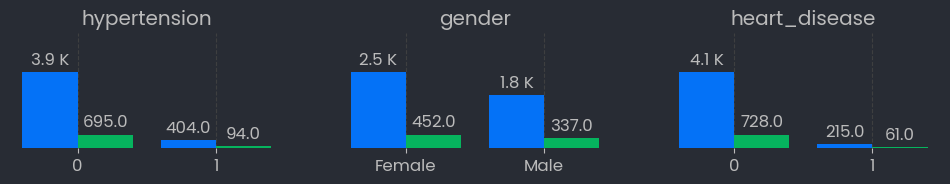

In [25]:
r, c = 1, 3
fig, ax = plt.subplots(r, c, figsize=(4*c, 1.5*r))
ax = ax.flatten()

my_binbar(ax[0], pivot_data(model.df, 'hypertension'), {})
my_binbar(ax[1], pivot_data(model.df, 'gender'), {})
my_binbar(ax[2], pivot_data(model.df, 'heart_disease'), {})

ax[0].set(title='hypertension')
ax[1].set(title='gender')
ax[2].set(title='heart_disease')

plt.show()

In [26]:
data = pivot_data(model.df_matched, 'heart_disease').T
data['Total'] = data.sum(axis=1)
data['ratio'] = data[True]/data['Total']
data[['ratio']].T.to_clipboard()


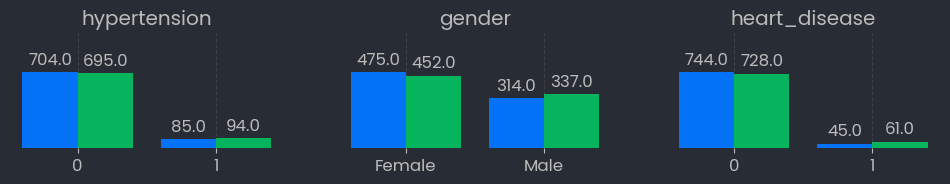

In [27]:
r, c = 1, 3
fig, ax = plt.subplots(r, c, figsize=(4*c, 1.5*r))
ax = ax.flatten()

my_binbar(ax[0], pivot_data(model.df_matched, 'hypertension'), {})
my_binbar(ax[1], pivot_data(model.df_matched, 'gender'), {})
my_binbar(ax[2], pivot_data(model.df_matched, 'heart_disease'), {})

ax[0].set(title='hypertension')
ax[1].set(title='gender')
ax[2].set(title='heart_disease')

plt.show()

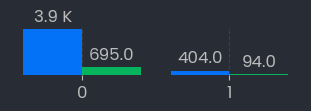

In [28]:
# Data Preparation

df_data = model.df.pivot_table(
    columns='hypertension',
    index='smoking_status_smokes',
    values='stroke',
    aggfunc='count'
)

# Transforming
df_data.columns = df_data.columns
categories = df_data.columns.values
values = {idx: df_data.loc[idx].values for idx in df_data.index}

# Peparation
x = np.arange(len(categories))  # the label locations
width = 0.4  # the width of the bars
n_groups = len(values)

fig, ax = plt.subplots(figsize=(3, 1), layout='constrained')

ax.set_axisbelow(True)
pallette_collors = [custom_colors[0], custom_colors[1]]
multiplier = 0
i = 0
for attribute, measurement in values.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, 
                   measurement, 
                   width, 
                   color=pallette_collors[i], alpha=1,
                   label=attribute)
    ax.bar_label(rects, labels=map(best_format, measurement), padding=3)
    multiplier += 1
    i += 1
group_centers = x + width * (n_groups / 2 - 0.5)
ax.set_xticks(group_centers, categories)
ax.set_yticks([])
ax.set_frame_on(False)

plt.show()

## SMD

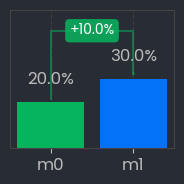

In [29]:

def custom_bar_arrow(categories, values, ax, cmap="tab10"):
    """
    Plot a vertical bar chart on the given axes.

    Parameters
    ----------
    categories : list
        Category labels for the bars.
    values : list
        Heights of the bars.
    ax : matplotlib.axes.Axes
        Axes object to plot on.
    cmap : str or Colormap, optional
        Colormap name or Colormap object for bar colors.
    """

    green, red = '#06b45e', '#fc3d51'

    def to_percent(v, decimals=0, already_fraction=True):
        """
        v: number or None
        already_fraction=True means 0.12 -> "12%"
        already_fraction=False means 12 -> "12%"
        """
        if v is None:
            return ""
        try:
            v = float(v)
        except (TypeError, ValueError):
            return ""

        pct = v * 100 if already_fraction else v
        return f"{pct:.{decimals}f}%"

    # Get colors from colormap
    bar_colors = [green, blue]
    bars = ax.bar(x=categories, height=values, color=bar_colors)
    ax.bar_label(container=bars, labels=[to_percent(v, decimals=1) for v in values], padding=10)
    ymax = max(values) * 2
    ax.set(yticks=[], ylim=(0, ymax))
    ax.set_axisbelow(True)
    ax.set_frame_on(True)
    mid_x = (bars[0].get_x() + bars[0].get_width()/2 + bars[1].get_x() + bars[1].get_width()/2) / 2
    mid_y = max(values) * 1.7
    pct_change = 100*(values[1] - values[0])
    pct_text = f"{pct_change:+.1f}%"
    bbox_color = green if pct_change >= 0 else red

    # Annotate with background color
    annotation = ax.annotate(
        pct_text,
        xy=(mid_x, mid_y),
        xytext=(0, 0),
        textcoords='offset points',
        ha='center', va='center',
        fontsize=10,
        color='white',
        bbox=dict(boxstyle="round,pad=0.3", fc=bbox_color, ec='none', alpha=0.85)
    )

    # Define arrow start and end points
    # Arrow from top of first bar to top of second bar
    bar0 = bars[0]
    bar1 = bars[1]
    x0 = bar0.get_x() + bar0.get_width() / 2
    y0 = bar0.get_height()
    x1 = bar1.get_x() + bar1.get_width() / 2
    y1 = bar1.get_height()
    # Draw two arrows: from bar0 to mid, and from mid to bar1
    arrow1 = FancyArrowPatch(
        posA=(x0, y0), posB=(mid_x, mid_y),
        arrowstyle="-|>", lw=1.5, color=bbox_color, alpha=0.5,
        connectionstyle="angle,angleA=90,angleB=0"
    )
    arrow2 = FancyArrowPatch(
        posA=(mid_x, mid_y), posB=(x1, y1),
        arrowstyle="-|>", lw=1.5, color=bbox_color, alpha=0.5,
        connectionstyle="angle,angleA=0,angleB=90"
    )
    ax.add_patch(arrow1)
    ax.add_patch(arrow2)

    return ax


if __name__ == "__main__":

    categories = ["m0", "m1"]
    values = [0.2, 0.3]

    fig, ax = plt.subplots(figsize=(2, 2))
    custom_bar_arrow(categories, values, ax, cmap='tab10')
    plt.tight_layout()
    plt.show()

In [30]:
outcome

'stroke'

In [31]:
treatment

'smoking_status_smokes'

In [32]:
smoke_stroke = model.df.pivot_table(
    index='smoking_status_smokes',
    columns='stroke',
    values='hypertension',
    aggfunc='count'
)

smoke_stroke_matched = model.df_matched.pivot_table(
    index='smoking_status_smokes',
    columns='stroke',
    values='hypertension',
    aggfunc='count'
)


In [33]:
smoke_stroke.to_clipboard()

In [34]:
smoke_stroke_matched.to_clipboard()

In [35]:

stroke_by_treatment = model.df_matched.groupby('smoking_status_smokes')[['stroke']].sum()
stroke_by_treatment 

,stroke
smoking_status_smokes,
False,31
True,42


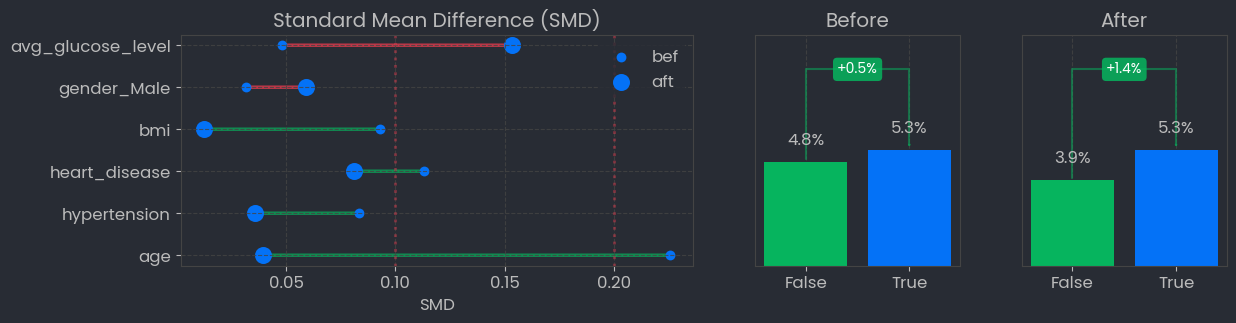

In [36]:
from matplotlib.patches import FancyArrowPatch
r, c = 1, 3
fig, ax = plt.subplots(r, c, figsize=(4.5*c, 3*r), width_ratios=(50,20,20))
ax = ax.flatten()

# Before Matching
stroke_by_treatment = model.df.groupby(treatment)[[outcome]].mean()
categories = stroke_by_treatment.index.values
values = stroke_by_treatment['stroke'].values
custom_bar_arrow(categories=categories,
                 values=values,
                 ax=ax[1])
ax[1].set_title('Before')
ax[1].set_xticks(ticks=[0,1], labels=('False', 'True'))

# After Matching
stroke_by_treatment = model.df_matched.groupby(treatment)[[outcome]].mean()
categories = stroke_by_treatment.index.values
values = stroke_by_treatment['stroke'].values
custom_bar_arrow(categories=categories,
                 values=values,
                 ax=ax[2])
ax[2].set_title('After')
ax[2].set_xticks(ticks=[0,1], labels=('False', 'True'))

# Comparing SMD
x1 = model.df_smd.smd_bef.values
x2 = model.df_smd.smd_aft.values
y = model.df_smd.index.values
labels = model.df_smd.features.values

for i in range(len(y)):
    color = red if x2[i] > x1[i] else green
    arrow = FancyArrowPatch(
        posA=(x1[i], y[i]),
        posB=(x2[i], y[i]),
        arrowstyle="-",
        color=color,
        lw=2.5,
        mutation_scale=12,
        alpha=0.7
    )
    ax[0].add_patch(arrow)

ax[0].scatter(x1, y, color=custom_colors[0], s=50, label='bef')
ax[0].scatter(x2, y, color=custom_colors[0], s=150, label='aft')
ax[0].set_yticks(y, labels=labels)
ax[0].axvline(0.1, color=red, linestyle=':', alpha=0.4)
ax[0].axvline(0.2, color=red, linestyle=':', alpha=0.4)
ax[0].legend(loc='upper right')
ax[0].set_title('Standard Mean Difference (SMD)')
ax[0].set(xlabel='SMD')

plt.savefig('output/out_1.png')
plt.show()

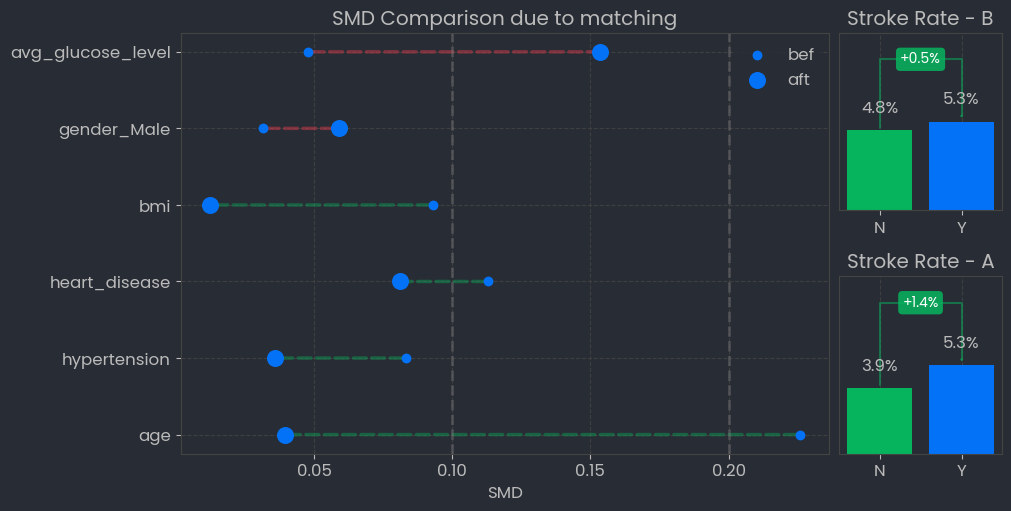

In [43]:
fig, ax = plt.subplot_mosaic([[0,1], [0,2]], figsize=(10,5), layout="constrained", width_ratios=(40,10))

# Before Matching
stroke_by_treatment = model.df.groupby(treatment)[[outcome]].mean()
categories = stroke_by_treatment.index.values
values = stroke_by_treatment['stroke'].values
custom_bar_arrow(categories=categories,
                 values=values,
                 ax=ax[1])
ax[1].set_title('Stroke Rate - B')
ax[1].set_xticks(ticks=[0,1], labels=('N', 'Y'))

# After Matching
stroke_by_treatment = model.df_matched.groupby(treatment)[[outcome]].mean()
categories = stroke_by_treatment.index.values
values = stroke_by_treatment['stroke'].values
custom_bar_arrow(categories=categories,
                 values=values,
                 ax=ax[2])
ax[2].set_title('Stroke Rate - A')
ax[2].set_xticks(ticks=[0,1], labels=('N', 'Y'))

# Comparing SMD
x1 = model.df_smd.smd_bef.values
x2 = model.df_smd.smd_aft.values
y = model.df_smd.index.values
labels = model.df_smd.features.values

for i in range(len(y)):
    color = red if x2[i] > x1[i] else green
    arrow = FancyArrowPatch(
        posA=(x1[i], y[i]),
        posB=(x2[i], y[i]),
        arrowstyle="-",
        color=color,
        lw=2.5,
        ls='--',
        mutation_scale=12,
        alpha=0.4
    )
    ax[0].add_patch(arrow)

ax[0].scatter(x1, y, color=custom_colors[0], s=50, label='bef')
ax[0].scatter(x2, y, color=custom_colors[0], s=150, label='aft')
ax[0].set_yticks(y, labels=labels)
ax[0].axvline(0.1, color='gray', linestyle='--', alpha=0.4)
ax[0].axvline(0.2, color='gray', linestyle='--', alpha=0.4)
ax[0].legend(loc='upper right')
ax[0].set_title('SMD Comparison due to matching')
ax[0].set(xlabel='SMD')
ax[0].set_axisbelow(True)

# plt.savefig('output/out_1.png')
plt.show()